In [445]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import powerlaw
import scipy.stats as stats
import pm4py

In [446]:
# Load dataset
filepath = "generated/preprocessed_dataset.csv"
df = pd.read_csv(filepath, parse_dates=["time:timestamp"])

df["case:concept:name"] = df["case:concept:name"].astype(str)
df["start_date"]= pd.to_datetime(df["start_date"])
df["time:timestamp"]= pd.to_datetime(df["time:timestamp"])

df.head()

,urgency,responsible_physician,disease,start_date,time:timestamp,concept:name,item,prescription_date,process_time,quantity,readmission_status,outlier_label,@@index,@@case_index,case:concept:name
0,Não informado,Médico 72,J11.1 Influenza c/out manif resp dev virus n ident,2020-07-21 10:22:00+00:00,2020-07-21 10:22:00+00:00,Atendimento,Atendimento,NaN,0.0,0.0,Sem retorno,outlier,0,0,5446538
1,Não informado,Médico 72,J11.1 Influenza c/out manif resp dev virus n ident,2020-07-21 10:45:00+00:00,2020-07-21 10:49:00+00:00,Triagem,Triagem,NaN,0.0,0.0,Sem retorno,outlier,1,0,5446538
2,Não informado,Médico 72,J11.1 Influenza c/out manif resp dev virus n ident,2020-07-21 11:01:00+00:00,2020-07-21 11:01:00+00:00,Exames Laboratoriais,Coronavírus COVID-19 - Diagnóstico Molecular (Pardini),2020-07-21 10:51:00+00:00,9.0,1.0,Sem retorno,outlier,2,0,5446538
3,Não informado,Médico 72,J11.1 Influenza c/out manif resp dev virus n ident,2020-07-21 11:32:00+00:00,2020-07-21 11:32:00+00:00,Consulta,Consulta,NaN,0.0,0.0,Sem retorno,outlier,3,0,5446538
4,Não informado,Médico 72,J11.1 Influenza c/out manif resp dev virus n ident,2020-07-21 19:27:00+00:00,2020-07-21 19:27:00+00:00,Alta,Alta para completar tratamento,NaN,0.0,0.0,Sem retorno,outlier,4,0,5446538


In [457]:
variants_dict = pm4py.get_variants(df)

# Compute frequencies
variants_df = pd.DataFrame(list(variants_dict.items()), columns=["variant", "frequency"])
variants_df["percentage"] = 100 * variants_df["frequency"] / variants_df["frequency"].sum()

# Sort by frequency
variants_df = variants_df.sort_values("frequency", ascending=False).reset_index(drop=True)

# Compute variant length
variants_df["variant_length"] = [len(variant) for variant in variants_df["variant"]]

# Create a variable for the distribution 
distribution = variants_df["frequency"]

total_cases = sum(distribution)
cumulative_coverage = np.cumsum(distribution) / total_cases

print(f"Total number of cases: {total_cases}")
print(f"Number of unique variants: {len(variants_df)}")
print(f"Top 10 variants cover: {variants_df["percentage"].head(10).sum():.2f}% of traces")

# Find the index where coverage >= 80%
k_80 = np.argmax(cumulative_coverage >= 0.80) + 1  # +1 for 1-based indexing
print(f"Top {k_80} variants ({(k_80 / len(variants_df)) * 100:.2f}% of total) cover 80% of cases (empirical)")

# Find the index where coverage >= 90%
k_90 = np.argmax(cumulative_coverage >= 0.90) + 1  # +1 for 1-based indexing
print(f"Top {k_90} variants ({(k_90 / len(variants_df)) * 100:.2f}% of total) cover 90% of cases (empirical)")

variants_df

Total number of cases: 436
Number of unique variants: 103
Top 10 variants cover: 76.83% of traces
Top 17 variants (16.50% of total) cover 80% of cases (empirical)
Top 60 variants (58.25% of total) cover 90% of cases (empirical)


,variant,frequency,percentage,variant_length
0,"(Atendimento, Triagem, Consulta, Alta)",247,56.651376,4
1,"(Atendimento, Triagem, Consulta, Exames de Imagem, Alta)",49,11.238532,5
2,"(Atendimento, Triagem, Consulta, Exames Laboratoriais, Alta)",12,2.752294,5
3,"(Atendimento, Triagem, Consulta, Exames Laboratoriais, Exames Laboratoriais, Exames de Imagem, Alta)",8,1.834862,7
4,"(Atendimento, Triagem, Consulta, Exames Laboratoriais, Exames de Imagem, Alta)",4,0.917431,6
...,...,...,...,...
98,"(Atendimento, Triagem, Consulta, Materiais Hospitalares, Materiais Hospitalares, Materiais Hospitalares, Materiais Hospitalares, Medicamentos, Medicamentos, Medicamentos, Medicamentos, Exames Laboratoriais, Exames Laboratoriais, Exames Laboratoriais, Exames de Imagem, Alta)",1,0.229358,16
99,"(Atendimento, Triagem, Consulta, Exames Laboratoriais, Exames Laboratoriais, Exames Laboratoriais, Exames Laboratoriais, Exames de Imagem, Alta)",1,0.229358,9
100,"(Atendimento, Consulta, Triagem, Materiais Hospitalares, Materiais Hospitalares, Medicamentos, Medicamentos, Materiais Hospitalares, Materiais Hospitalares, Alta)",1,0.229358,10
101,"(Atendimento, Consulta, Medicamentos, Exames Laboratoriais, Alta)",1,0.229358,5


### Variant Distribution Analysis

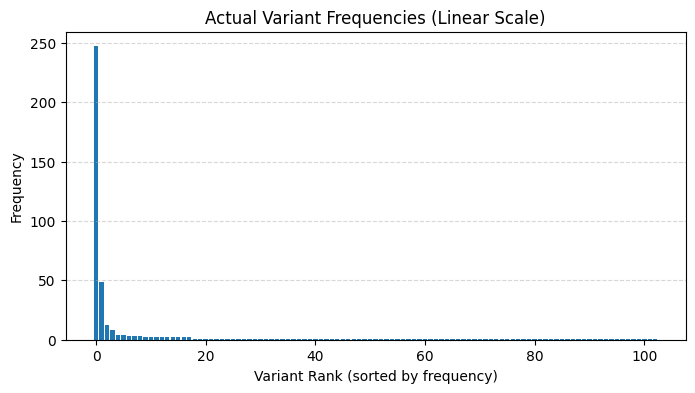

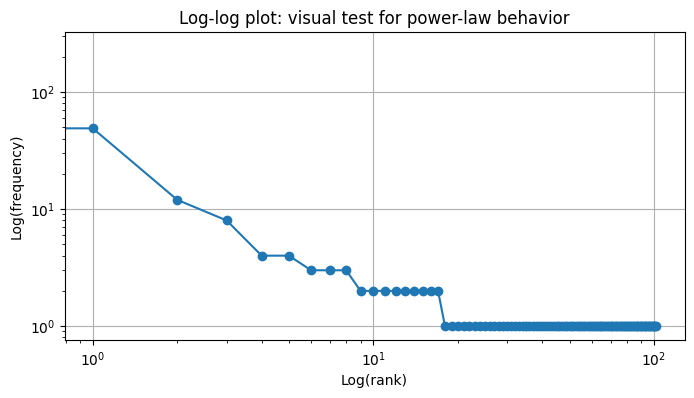

In [448]:
# Plot the distribution of variant frequencies
plt.figure(figsize=(8, 4))
plt.bar(range(0, len(distribution)), distribution)
plt.title("Actual Variant Frequencies (Linear Scale)")
plt.xlabel("Variant Rank (sorted by frequency)")
plt.ylabel("Frequency")
plt.grid(True, axis='y', ls="--", alpha=0.5)
plt.show()

# Log-log plot to visually assess power-law behavior
plt.figure(figsize=(8, 4))
plt.loglog(range(0, len(distribution)), distribution, marker='o', linestyle='solid')
plt.xlabel('Log(rank)')
plt.ylabel('Log(frequency)')
plt.title('Log-log plot: visual test for power-law behavior')
plt.grid(True)
plt.show()

Calculating best minimal value for power law fit


Fitting xmin: 100%|██████████| 6/6 [00:00<00:00, 1643.43it/s]

--- Power Law Fit Results ---
Alpha (α): 2.604
x_min: 1.0
KS Distance (D): 0.058
Power Law vs Lognormal: R = -6.854, p = 0.251
No significant difference between power law and lognormal fits, both models explain the data equally well.



c:\Users\milan\AppData\Local\Programs\Python\Python313\Lib\site-packages\powerlaw\distributions.py:2792: RuntimeWarning: invalid value encountered in divide
  return likelihoods/norm


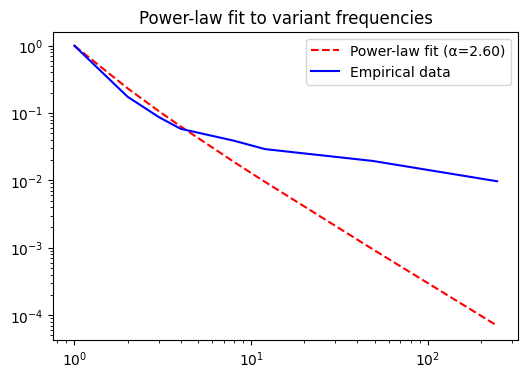

In [449]:
# Fit power law and compare to lognormal  
fit = powerlaw.Fit(distribution, discrete=True)  
R, p = fit.distribution_compare('power_law', 'lognormal')  

# Print results  
print("--- Power Law Fit Results ---")  
print(f"Alpha (α): {fit.power_law.alpha:.3f}")  
print(f"x_min: {fit.power_law.xmin}")  
print(f"KS Distance (D): {fit.power_law.D:.3f}")  
print(f"Power Law vs Lognormal: R = {R:.3f}, p = {p:.3f}")  

if p < 0.05:
    if R > 0:  
        print("Power law is a better fit than lognormal.")  
    else:  
        print("Lognormal may be a better fit.")  
else:
    print("No significant difference between power law and lognormal fits, both models explain the data equally well.")



# Plot fit for comparison
plt.figure(figsize=(6,4))
fit.power_law.plot_ccdf(color='r', linestyle='--', label=f'Power-law fit (α={fit.power_law.alpha:.2f})') # Theoretical PDF (from fitted α)
fit.plot_ccdf(color='b', label='Empirical data') # Empirical density (from  data)
plt.legend()
plt.title('Power-law fit to variant frequencies')
plt.show()

Total number of cases after cutoff: 351
Percentage of cases over cutoff variant frequency: 80.50%
Number of unique variants after cutoff: 18


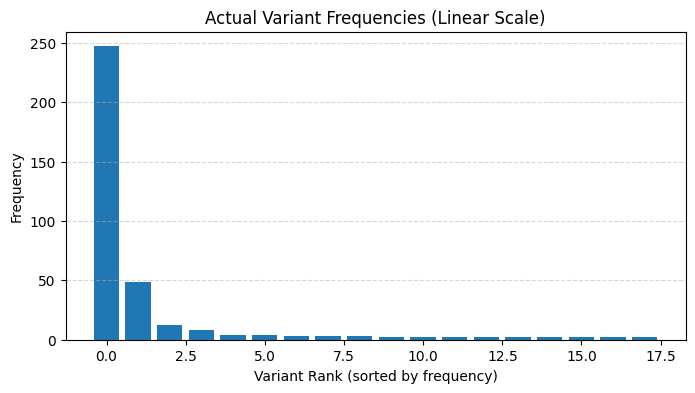

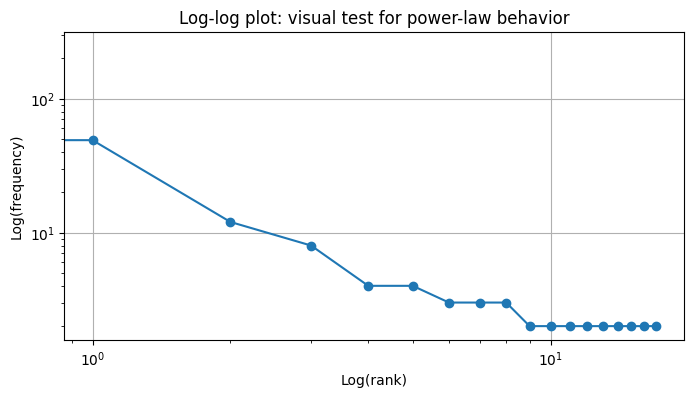

In [462]:
variant_cutoff = variants_df[variants_df["frequency"] > fit.power_law.xmin]

distribution_cutoff = variant_cutoff["frequency"]

total_cases_cutoff = sum(distribution_cutoff)

print(f"Total number of cases after cutoff: {total_cases_cutoff}")
print(f"Percentage of cases over cutoff variant frequency: {total_cases_cutoff / total_cases * 100:.2f}%")
print(f"Number of unique variants after cutoff: {len(variant_cutoff)}")

# Plot the distribution of variant frequencies
plt.figure(figsize=(8, 4))
plt.bar(range(0, len(distribution_cutoff)), distribution_cutoff)
plt.title("Actual Variant Frequencies (Linear Scale)")
plt.xlabel("Variant Rank (sorted by frequency)")
plt.ylabel("Frequency")
plt.grid(True, axis='y', ls="--", alpha=0.5)
plt.show()

# Log-log plot to visually assess power-law behavior
plt.figure(figsize=(8, 4))
plt.loglog(range(0, len(distribution_cutoff)), distribution_cutoff, marker='o', linestyle='solid')
plt.xlabel('Log(rank)')
plt.ylabel('Log(frequency)')
plt.title('Log-log plot: visual test for power-law behavior')
plt.grid(True)
plt.show()

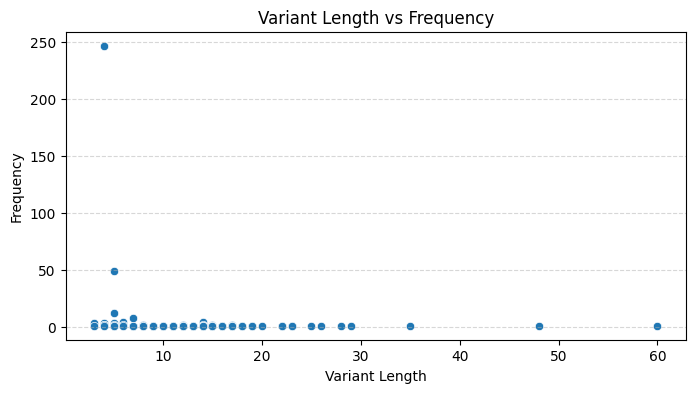

In [451]:
# Plot variant length vs frequency
plt.figure(figsize=(8,4))
sns.scatterplot(data=variants_df, x="variant_length", y="frequency")
plt.title("Variant Length vs Frequency")
plt.xlabel("Variant Length")
plt.ylabel("Frequency")
plt.grid(True, axis="y", ls="--", alpha=0.5)
plt.show()

In [452]:
# Since frequency is non-normal, use Spearman's correlation to test the correlation between variant length and frequency
corr, p_val = stats.spearmanr(variants_df["variant_length"], variants_df["frequency"])
print(f"Spearman correlation coefficient: {corr:.4f}")
print(f"P-value: {p_val:.4e}")

if p_val < 0.05:
    print("\n✅ There is a statistically significant correlation between variant length and frequency.")
else:
    print("\n❌ There is NOT statistically significant correlation between variant length and frequency.")

Spearman correlation coefficient: -0.4423
P-value: 2.9040e-06

✅ There is a statistically significant correlation between variant length and frequency.


Conclusion:
- About 16% of the variants cover 80% of the variants.
- The process variants distribution, which has a very long tail, don't follow a power law distribution. There are a lot of unique variant that occur only once.
- Variant length and frequency are negatively correlated with a correlation coefficient of -0.4423. The longer a variant is, the less frequent it is.

### Variant duration analysis

In [453]:
# --- Step 1: assign variant string to each case ---
# variants_dict = {tuple_of_activities: frequency} from pm4py.get_variants()
# We need to rebuild case→variant mapping

case_variant_map = {}
for variant_tuple, freq in variants_dict.items():
    # pm4py.get_variants on a DataFrame returns {variant_tuple: count}
    # To get case IDs per variant we need get_variants on the event log
    pass

# Rebuild properly: get variant per case directly from the df
df_sorted = df.sort_values(["case:concept:name", "time:timestamp"])

case_to_variant = (
    df_sorted.groupby("case:concept:name")["concept:name"]
    .apply(tuple)
    .reset_index()
    .rename(columns={"concept:name": "variant_tuple"})
)
case_to_variant["variant_str"] = case_to_variant["variant_tuple"].apply(
    lambda x: " → ".join(x)
)

In [454]:
# --- Step 2: compute duration per case ---
case_duration = (
    df.groupby("case:concept:name")["time:timestamp"]
    .agg(
        ts_start="min",
        ts_end="max"
    )
    .assign(duration_min=lambda x: (x["ts_end"] - x["ts_start"]).dt.total_seconds() / 60)
    .reset_index()[["case:concept:name", "duration_min"]]
)

# Merge case duration with variant assignment
case_df = case_to_variant.merge(case_duration, on="case:concept:name")

# --- Step 3: aggregate duration statistics per variant ---
variant_duration = (
    case_df.groupby("variant_str")["duration_min"]
    .agg(
        mean_duration_min="mean",
        median_duration_min="median",
        std_duration_min="std",
        min_duration_min="min",
        max_duration_min="max",
        n_cases="count" # cross-check con frequency
    )
    .round(2)
    .reset_index()
)

In [455]:
# Aggiungi variant_str a variants_df per il merge
variants_df["variant_str"] = variants_df["variant"].apply(lambda x: " → ".join(x))

# Merge
variants_enriched = variants_df.merge(variant_duration, on="variant_str", how="left")

# Colonne finali ordinate
variants_enriched = variants_enriched[[
    "variant_str", "frequency", "percentage", "variant_length",
    "mean_duration_min", "median_duration_min", "std_duration_min",
    "min_duration_min", "max_duration_min"
]].sort_values("frequency", ascending=False).reset_index(drop=True)

variants_enriched

,variant_str,frequency,percentage,variant_length,mean_duration_min,median_duration_min,std_duration_min,min_duration_min,max_duration_min
0,Atendimento → Triagem → Consulta → Alta,247,56.651376,4,78.00,57.0,71.74,9.0,386.0
1,Atendimento → Triagem → Consulta → Exames de Imagem → Alta,49,11.238532,5,122.51,101.0,74.18,41.0,395.0
2,Atendimento → Triagem → Consulta → Exames Laboratoriais → Alta,12,2.752294,5,87.92,79.5,55.74,23.0,207.0
3,Atendimento → Triagem → Consulta → Exames Laboratoriais → Exames Laboratoriais → Exames de Imagem → Alta,8,1.834862,7,221.62,201.0,84.29,123.0,346.0
4,Atendimento → Triagem → Consulta → Exames Laboratoriais → Exames de Imagem → Alta,4,0.917431,6,170.50,168.5,74.87,82.0,263.0
...,...,...,...,...,...,...,...,...,...
98,Atendimento → Triagem → Consulta → Materiais Hospitalares → Materiais Hospitalares → Materiais Hospitalares → Materiais Hospitalares → Medicamentos → Medicamentos → Medicamentos → Medicamentos → Exames Laboratoriais → Exames Laboratoriais → Exames Laboratoriais → Exames de Imagem → Alta,1,0.229358,16,226.00,226.0,NaN,226.0,226.0
99,Atendimento → Triagem → Consulta → Exames Laboratoriais → Exames Laboratoriais → Exames Laboratoriais → Exames Laboratoriais → Exames de Imagem → Alta,1,0.229358,9,152.00,152.0,NaN,152.0,152.0
100,Atendimento → Consulta → Triagem → Materiais Hospitalares → Materiais Hospitalares → Medicamentos → Medicamentos → Materiais Hospitalares → Materiais Hospitalares → Alta,1,0.229358,10,160.00,160.0,NaN,160.0,160.0
101,Atendimento → Consulta → Medicamentos → Exames Laboratoriais → Alta,1,0.229358,5,108.00,108.0,NaN,108.0,108.0
